# Sistema de Detección de Placas y Pico y Placa — Pasto, Colombia

**Curso:** Inteligencia Artificial  
**Entregable:** Notebook de demostración técnica

---

## Descripción del problema

El **Pico y Placa** en Pasto, Nariño, es una medida de restricción vehicular que limita la circulación de vehículos según el último dígito de su placa y el día de la semana. El sistema opera de **7:30 AM a 7:00 PM, de lunes a viernes**, con pares de dígitos que rotan semanalmente en un ciclo de 5 semanas.

### Objetivo del proyecto

Implementar un sistema de escritorio en Python que:
1. Capture frames desde webcam, video o imagen estática
2. Detecte y lea la placa vehicular usando visión computacional e IA
3. Verifique en tiempo real si el vehículo tiene restricción
4. Ofrezca un asistente conversacional basado en un modelo Transformer (Gemini)

---

## Arquitectura general del sistema

```
[Webcam / Imagen / Video]
        │
        ▼ OpenCV — captura y preprocesamiento
  ┌─────────────┐
  │  detector.py │  ◄── EasyOCR (CRNN: CNN + LSTM)
  └──────┬──────┘      OpenALPR (Windows)
         │ placa detectada (ej: "EBM187")
         ▼
  ┌──────────────────┐
  │  pico_y_placa.py  │  ◄── lógica determinista + festivos
  └──────┬───────────┘
         │ {restringido: True/False, motivo, dígito, par_hoy}
         ▼
  ┌────────────┐
  │   gui.py   │  ◄── Tkinter, bbox verde/rojo, historial, multas
  └──────┬─────┘
         │ chat del usuario
         ▼
  ┌───────────────┐
  │ assistant.py  │  ◄── Gemini 2.5 Flash (Transformer decoder-only)
  └───────────────┘
```

---
## 1. Configuración del entorno

In [1]:
import sys
import os

# Cargar variables de entorno (.env con GEMINI_API_KEY)
try:
    from dotenv import load_dotenv
    load_dotenv(os.path.join('pico_y_placa', '.env'))
except ImportError:
    pass  # si no está instalado, Gemini usará la variable del sistema

# Agregar el módulo del proyecto al path
PROJECT_DIR = os.path.abspath('pico_y_placa')
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, date

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'monospace'

print('Entorno listo.')
print(f'OpenCV: {cv2.__version__}')
print(f'NumPy:  {np.__version__}')

Entorno listo.
OpenCV: 4.13.0
NumPy:  2.4.5


---
## 2. Modelos de IA utilizados — Arquitecturas

El proyecto usa **dos tipos de modelos de IA** con arquitecturas distintas:

### 2.1 EasyOCR — Red Neuronal CRNN

EasyOCR implementa una **CRNN** (Convolutional Recurrent Neural Network), que combina dos tipos de redes:

```
  Imagen de la placa
        │
        ▼
  ┌─────────────────────────────────────┐
  │  ENCODER — CNN (ResNet / VGG)       │  extrae características visuales
  │  Conv → Pool → Conv → Pool → ...    │  (bordes, formas, texturas)
  └──────────────┬──────────────────────┘
                 │ mapa de características (feature map)
                 ▼
  ┌─────────────────────────────────────┐
  │  DECODER — LSTM Bidireccional       │  lee la secuencia de izq. a der.
  │  → → → → → → → → → → → → →         │  y de der. a izq. simultáneamente
  │  ← ← ← ← ← ← ← ← ← ← ← ←         │
  └──────────────┬──────────────────────┘
                 │ secuencia de probabilidades por carácter
                 ▼
         CTC Loss / Decoder
                 │
                 ▼
            "EBM187"
```

**CTC (Connectionist Temporal Classification):** permite entrenar el modelo sin necesitar alineación exacta entre cada carácter y su posición en la imagen.

### 2.2 Google Gemini 2.5 Flash — Transformer decoder-only

Gemini sigue la arquitectura **Transformer decoder-only** (igual que GPT), diseñada para generación de texto:

```
  Prompt del usuario + contexto de fecha/par
        │
        ▼
  ┌─────────────────────────────────────┐
  │  Embedding de tokens                │
  ├─────────────────────────────────────┤
  │  Bloque Transformer × N capas:      │
  │   ┌──────────────────────────────┐  │
  │   │  Multi-Head Self-Attention   │  │  cada token "atiende" a todos
  │   │  (Masked — solo hacia atrás) │  │  los tokens anteriores
  │   ├──────────────────────────────┤  │
  │   │  Feed-Forward Network        │  │
  │   ├──────────────────────────────┤  │
  │   │  Layer Normalization         │  │
  │   └──────────────────────────────┘  │
  ├─────────────────────────────────────┤
  │  Capa de salida (softmax)           │  probabilidad del siguiente token
  └─────────────────────────────────────┘
        │  generación autoregresiva (token por token)
        ▼
  "Hoy el par restringido es 2-3, su placa termina en 7..."
```

**Diferencia clave:**
- **CRNN** → procesa una imagen y extrae texto (encoder visual + decoder secuencial)
- **Transformer** → procesa texto y genera texto (decoder-only, autoregresivo)

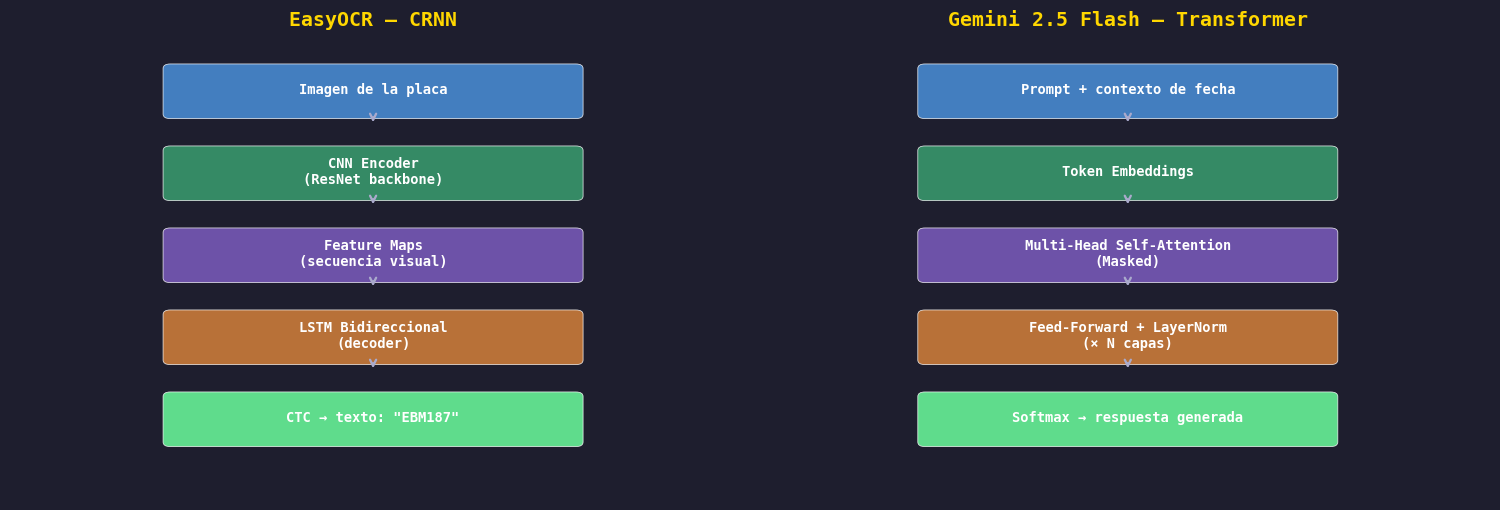

Diagrama guardado como arquitecturas_ia.png


In [2]:
# Diagrama visual de las arquitecturas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e2e')

# ── CRNN ──────────────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#2a2a3e')
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10)
ax1.axis('off')
ax1.set_title('EasyOCR — CRNN', color='#ffd700', fontsize=13, fontweight='bold', pad=12)

bloques_crnn = [
    (5, 9.0, 'Imagen de la placa', '#4a90d9'),
    (5, 7.2, 'CNN Encoder\n(ResNet backbone)', '#3a9e6f'),
    (5, 5.4, 'Feature Maps\n(secuencia visual)', '#7c5cbf'),
    (5, 3.6, 'LSTM Bidireccional\n(decoder)', '#d4813a'),
    (5, 1.8, 'CTC → texto: "EBM187"', '#6bff9e'),
]
for x, y, txt, col in bloques_crnn:
    ax1.add_patch(mpatches.FancyBboxPatch((x-2.8, y-0.55), 5.6, 1.0,
        boxstyle='round,pad=0.1', facecolor=col, alpha=0.85, edgecolor='white', lw=0.5))
    ax1.text(x, y, txt, ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    if y > 1.8:
        ax1.annotate('', xy=(x, y - 0.8), xytext=(x, y - 0.55),
                     arrowprops=dict(arrowstyle='->', color='#aaaacc', lw=1.5))

# ── Transformer ───────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#2a2a3e')
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Gemini 2.5 Flash — Transformer', color='#ffd700', fontsize=13, fontweight='bold', pad=12)

bloques_t = [
    (5, 9.0, 'Prompt + contexto de fecha', '#4a90d9'),
    (5, 7.2, 'Token Embeddings', '#3a9e6f'),
    (5, 5.4, 'Multi-Head Self-Attention\n(Masked)', '#7c5cbf'),
    (5, 3.6, 'Feed-Forward + LayerNorm\n(× N capas)', '#d4813a'),
    (5, 1.8, 'Softmax → respuesta generada', '#6bff9e'),
]
for x, y, txt, col in bloques_t:
    ax2.add_patch(mpatches.FancyBboxPatch((x-2.8, y-0.55), 5.6, 1.0,
        boxstyle='round,pad=0.1', facecolor=col, alpha=0.85, edgecolor='white', lw=0.5))
    ax2.text(x, y, txt, ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    if y > 1.8:
        ax2.annotate('', xy=(x, y - 0.8), xytext=(x, y - 0.55),
                     arrowprops=dict(arrowstyle='->', color='#aaaacc', lw=1.5))

plt.tight_layout(pad=2)
plt.savefig('arquitecturas_ia.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Diagrama guardado como arquitecturas_ia.png')

---
## 3. Pipeline de preprocesamiento de imagen

Antes de pasarle el frame a EasyOCR, se aplica una cadena de transformaciones para mejorar la calidad de la imagen y la precisión del OCR.

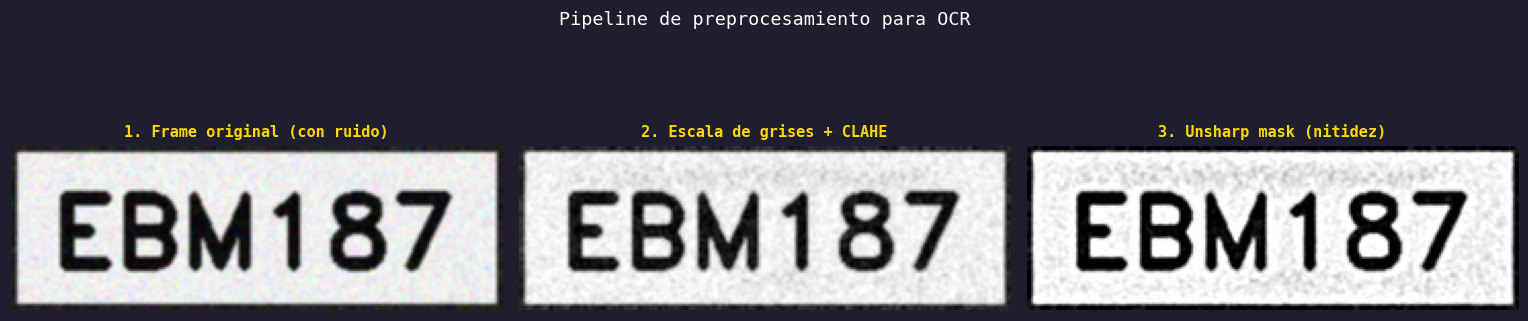

CLAHE normaliza el contraste en zonas oscuras o sobreexpuestas.
Unsharp mask acentúa los bordes de los caracteres para el OCR.


In [3]:
# Generamos una placa colombiana sintética para demostrar el pipeline
def crear_placa_sintetica(texto='EBM187', ruido=True):
    placa = np.ones((80, 240, 3), dtype=np.uint8) * 240  # fondo claro
    cv2.rectangle(placa, (0, 0), (239, 79), (30, 30, 30), 3)
    cv2.putText(placa, texto, (20, 58),
                cv2.FONT_HERSHEY_DUPLEX, 1.6, (10, 10, 10), 3)
    if ruido:
        noise = np.random.normal(0, 18, placa.shape).astype(np.int16)
        placa = np.clip(placa.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        placa = cv2.GaussianBlur(placa, (3, 3), 0)  # simular desenfoque leve
    return placa

frame_original = crear_placa_sintetica('EBM187', ruido=True)

# ── Pipeline de preprocesamiento ──────────────────────────────────────────────
def preprocesar(frame):
    gris  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gris  = clahe.apply(gris)
    blur  = cv2.GaussianBlur(gris, (0, 0), 3)
    sharp = cv2.addWeighted(gris, 1.5, blur, -0.5, 0)
    return gris, sharp

gris_base, gris_sharp = preprocesar(frame_original)

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
fig.patch.set_facecolor('#1e1e2e')

titulos  = ['1. Frame original (con ruido)', '2. Escala de grises + CLAHE', '3. Unsharp mask (nitidez)']
imagenes = [cv2.cvtColor(frame_original, cv2.COLOR_BGR2RGB), gris_base, gris_sharp]
cmaps    = [None, 'gray', 'gray']

for ax, img, titulo, cmap in zip(axes, imagenes, titulos, cmaps):
    ax.set_facecolor('#2a2a3e')
    ax.imshow(img, cmap=cmap)
    ax.set_title(titulo, color='#ffd700', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Pipeline de preprocesamiento para OCR', color='white', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('preprocesamiento.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('CLAHE normaliza el contraste en zonas oscuras o sobreexpuestas.')
print('Unsharp mask acentúa los bordes de los caracteres para el OCR.')

---
## 4. Detección de placa con EasyOCR

In [4]:
import easyocr
import re

print('Cargando modelo EasyOCR (CRNN)…')
reader = easyocr.Reader(['en'], gpu=False, verbose=False)
print('Modelo listo.')

def limpiar_placa(texto):
    texto = texto.upper().replace(' ', '').replace('-', '').replace('.', '')
    match = re.search(r'[A-Z]{3}\d{3}', texto)
    return match.group() if match else texto

# Probar con placa sintética preprocesada
resultados = reader.readtext(gris_sharp, detail=1, paragraph=False)

print(f'\nResultados EasyOCR sobre imagen preprocesada:')
print(f'{"Texto":<15} {"Confianza":>10}')
print('-' * 27)
for (_, texto, conf) in resultados:
    limpio = limpiar_placa(texto)
    es_placa = '✅' if re.match(r'^[A-Z]{3}\d{3}$', limpio) else '  '
    print(f'{es_placa} {limpio:<13} {conf*100:>8.1f}%')

# También probar con frame sin preprocesar
gris_sin_proc = cv2.cvtColor(frame_original, cv2.COLOR_BGR2GRAY)
res_sin = reader.readtext(gris_sin_proc, detail=1, paragraph=False)
print(f'\nSin preprocesamiento:')
for (_, texto, conf) in res_sin:
    limpio = limpiar_placa(texto)
    es_placa = '✅' if re.match(r'^[A-Z]{3}\d{3}$', limpio) else '  '
    print(f'{es_placa} {limpio:<13} {conf*100:>8.1f}%')

Cargando modelo EasyOCR (CRNN)…


Modelo listo.



Resultados EasyOCR sobre imagen preprocesada:
Texto            Confianza
---------------------------
✅ EBM187            88.9%

Sin preprocesamiento:
✅ EBM187            99.1%


---
## 5. Lógica de verificación Pico y Placa

Una vez detectada la placa, el módulo `pico_y_placa.py` determina si hay restricción. Esta parte es **determinista** — dado el texto de la placa y la fecha/hora, la respuesta siempre es exacta.

In [5]:
from pico_y_placa import verificar, obtener_par_restringido
from holidays import FESTIVOS

# ── Demostración con casos variados ───────────────────────────────────────────
# Semana del 25 may 2026 (lunes) → par restringido = 4-5
# Cálculo: REFERENCIA=04-may (base=8), 3 semanas después → (8+6)%10 = 4 → par [4,5]

casos = [
    ('ABC124', datetime(2026, 5, 25, 10,  0), 'Lunes 10am  — dígito 4 ESTÁ en par [4-5]'),
    ('EBM187', datetime(2026, 5, 25, 10,  0), 'Lunes 10am  — dígito 7 NO está en par [4-5]'),
    ('XYZ456', datetime(2026, 5, 25, 20, 30), 'Lunes 8:30pm — fuera de horario (fin 7pm)'),
    ('MNO890', datetime(2026, 5, 23, 10,  0), 'Sábado      — sin restricción de fin de semana'),
    ('ABC999', datetime(2026, 5, 25,  7,  0), 'Lunes 7am   — antes del horario (inicio 7:30am)'),
    ('ABC999', datetime(2026, 5,  1, 10,  0), 'Festivo     — Día del Trabajo'),
]

print(f'{"Placa":<8} {"Dígito":<8} {"Par hoy":<9} {"Resultado":<20} Motivo')
print('─' * 80)
for placa, dt, descripcion in casos:
    r      = verificar(placa, dt)
    estado = '❌ RESTRICCIÓN' if r['restringido'] else '✅ PUEDE CIRCULAR'
    par    = f"{r['par_hoy'][0]}-{r['par_hoy'][1]}" if r['par_hoy'] else 'N/A'
    print(f'{placa:<8} {r["digito"]:<8} {par:<9} {estado:<20} {descripcion}')

Placa    Dígito   Par hoy   Resultado            Motivo
────────────────────────────────────────────────────────────────────────────────
ABC124   4        4-5       ❌ RESTRICCIÓN        Lunes 10am  — dígito 4 ESTÁ en par [4-5]
EBM187   7        4-5       ✅ PUEDE CIRCULAR     Lunes 10am  — dígito 7 NO está en par [4-5]
XYZ456   6        4-5       ✅ PUEDE CIRCULAR     Lunes 8:30pm — fuera de horario (fin 7pm)
MNO890   0        N/A       ✅ PUEDE CIRCULAR     Sábado      — sin restricción de fin de semana
ABC999   9        4-5       ✅ PUEDE CIRCULAR     Lunes 7am   — antes del horario (inicio 7:30am)
ABC999   9        N/A       ✅ PUEDE CIRCULAR     Festivo     — Día del Trabajo


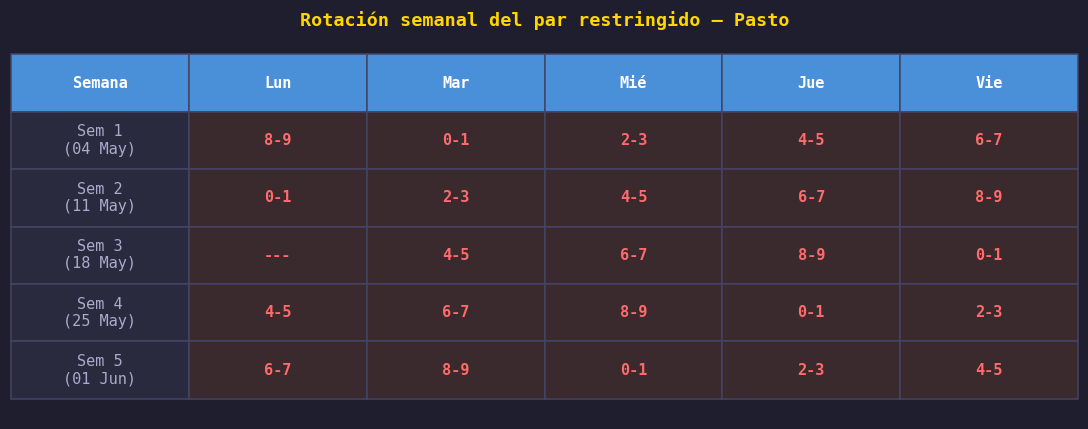

In [6]:
# ── Tabla de rotación semanal ─────────────────────────────────────────────────
from datetime import timedelta

DIAS = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie']
inicio = date(2026, 5, 4)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#2a2a3e')
ax.axis('off')
ax.set_title('Rotación semanal del par restringido — Pasto', color='#ffd700', fontsize=12, fontweight='bold')

semanas = 5
tabla   = []
for s in range(semanas):
    fila = [f'Sem {s+1}\n({(inicio + timedelta(weeks=s)).strftime("%d %b")})']
    for d in range(5):
        fecha = inicio + timedelta(weeks=s, days=d)
        par   = obtener_par_restringido(fecha)
        fila.append(f'{par[0]}-{par[1]}' if par else '---')
    tabla.append(fila)

cols   = ['Semana'] + DIAS
colores = [['#1e1e2e'] + ['#c0392b' if i % 2 == 0 else '#7c5cbf' for i in range(5)] for _ in range(semanas)]

t = ax.table(cellText=tabla, colLabels=cols, cellLoc='center', loc='center')
t.auto_set_font_size(False)
t.set_fontsize(10)
for (r, c), cell in t.get_celld().items():
    cell.set_edgecolor('#444466')
    if r == 0:
        cell.set_facecolor('#4a90d9')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 0:
        cell.set_facecolor('#2a2a3e')
        cell.set_text_props(color='#aaaacc')
    else:
        cell.set_facecolor('#3a2a2e')
        cell.set_text_props(color='#ff6b6b', fontweight='bold')
    cell.set_height(0.15)

plt.tight_layout()
plt.savefig('rotacion_semanal.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## 6. Asistente conversacional — Gemini 2.5 Flash (Transformer)

El asistente usa **Gemini 2.5 Flash** de Google, un LLM con arquitectura Transformer decoder-only. Recibe un system prompt que restringe las respuestas al dominio de pico y placa, más un contexto dinámico con la fecha y el par restringido del día.

### Estrategia de contexto

En lugar de hacer fine-tuning del modelo, se inyecta el contexto relevante directamente en cada mensaje:

```
mensaje_usuario + contexto_dinamico → Gemini → respuesta
```

Esto permite que el modelo general responda correctamente sin haber sido entrenado en datos de Pasto. El motor principal es **Ollama (Llama 3.2 3B)** corriendo localmente. Si Ollama no está disponible o da respuestas de baja calidad, el sistema cae automáticamente a **Gemini Flash** como respaldo.

> **Nota:** Los modelos pequeños (3B parámetros) a veces cometen errores de razonamiento aritmético simple (como identificar el último dígito de una cadena). Gemini Flash es el motor recomendado para producción.

In [7]:
# Demostración del sistema de contexto dinámico que se inyecta en cada mensaje
from holidays import FESTIVOS

def construir_contexto(fecha_hora: datetime) -> dict:
    dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
    par  = obtener_par_restringido(fecha_hora.date())
    return {
        'dia'       : dias[fecha_hora.weekday()],
        'fecha'     : fecha_hora.strftime('%d/%m/%Y'),
        'par_hoy'   : f'{par[0]}-{par[1]}' if par else 'Sin restricción',
        'es_festivo': fecha_hora.date() in FESTIVOS,
    }

ahora    = datetime.now()
contexto = construir_contexto(ahora)

festivo_txt = 'Hoy es festivo, no hay restricción.' if contexto['es_festivo'] else 'Hoy no es festivo.'
contexto_str = (
    f"[Contexto del sistema — {contexto['dia']}, "
    f"{contexto['fecha']}: par restringido hoy = {contexto['par_hoy']}. {festivo_txt}]"
)

print('Contexto dinámico inyectado en cada mensaje a Gemini:')
print(contexto_str)
print()
print('Este contexto se concatena con el mensaje del usuario antes de enviarlo al modelo.')
print('Así Gemini siempre sabe la fecha actual y el par restringido sin necesidad de fine-tuning.')

Contexto dinámico inyectado en cada mensaje a Gemini:
[Contexto del sistema — Miércoles, 20/05/2026: par restringido hoy = 6-7. Hoy no es festivo.]

Este contexto se concatena con el mensaje del usuario antes de enviarlo al modelo.
Así Gemini siempre sabe la fecha actual y el par restringido sin necesidad de fine-tuning.


In [8]:
# Consulta real al asistente con Gemini Flash (requiere GEMINI_API_KEY en .env)
import os
from assistant import preguntar, reiniciar_chat

reiniciar_chat()  # sesión limpia para la demo

preguntas_demo = [
    '¿Puede circular hoy un vehículo con placa ABC124?',
    '¿Cuál es el horario del pico y placa en Pasto?',
    '¿El 1 de mayo hay restricción?',
]

fecha_demo = datetime(2026, 5, 25, 10, 0)
par        = obtener_par_restringido(fecha_demo.date())
contexto   = {
    'dia'            : 'Lunes',
    'fecha'          : '25/05/2026',
    'par_hoy'        : f'{par[0]}-{par[1]}' if par else 'Sin restricción',
    'es_festivo'     : False,
    # Placa detectada activa (ABC124, dígito 4, en par [4-5] → restringida)
    'placa_detectada': 'ABC124',
    'digito'         : 4,
    'restringido'    : True,
}

print(f'Contexto inyectado → par hoy: {contexto["par_hoy"]} | '
      f'placa activa: {contexto["placa_detectada"]} (dígito {contexto["digito"]})\n')
print('─' * 60)

for pregunta in preguntas_demo:
    print(f'Usuario: {pregunta}')
    try:
        respuesta = preguntar(pregunta, contexto)
        print(f'Asistente: {respuesta}')
    except Exception as e:
        print(f'[Error] {e}')
    print()

Contexto inyectado → par hoy: 4-5 | placa activa: ABC124 (dígito 4)

────────────────────────────────────────────────────────────
Usuario: ¿Puede circular hoy un vehículo con placa ABC124?


[asistente] Motor activo: Ollama (local)
Asistente: Sí, el vehículo con la placa ABC124 tiene restricción activa porque su último dígito es un 4, que corresponde al par restringido para este día.

Usuario: ¿Cuál es el horario del pico y placa en Pasto?


Asistente: El horario del pico y placa en Pasto es de 7:30 AM a 7:00 PM.

Usuario: ¿El 1 de mayo hay restricción?


Asistente: El 1 de mayo es un día festivo en Colombia, por lo que no hay restricción para el tráfico en Pasto.



---
## 7. Demo visual completa — frame → detección → verificación

════════════════════════════════════════════════════════════
CASO 1 — Placa ABC124 (dígito 4, par hoy = 4-5) → RESTRICCIÓN
════════════════════════════════════════════════════════════


/tmp/ipykernel_11820/1951069148.py:63: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/cristian/Proyectos/pico_y_placa_OpenALPR/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


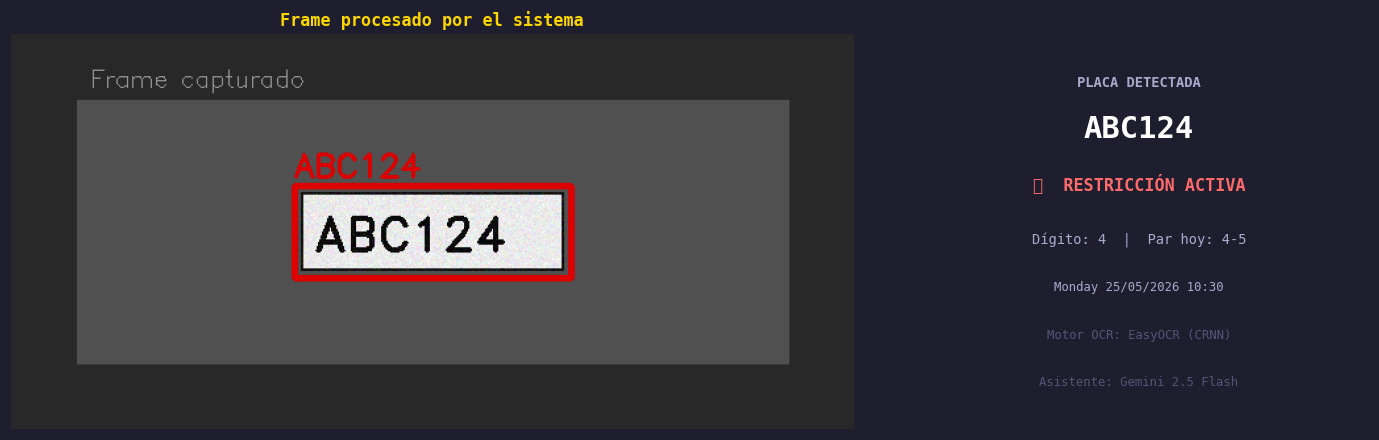

════════════════════════════════════════════════════════════
CASO 2 — Placa EBM187 (dígito 7, par hoy = 4-5) → PUEDE CIRCULAR
════════════════════════════════════════════════════════════


/tmp/ipykernel_11820/1951069148.py:63: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/cristian/Proyectos/pico_y_placa_OpenALPR/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


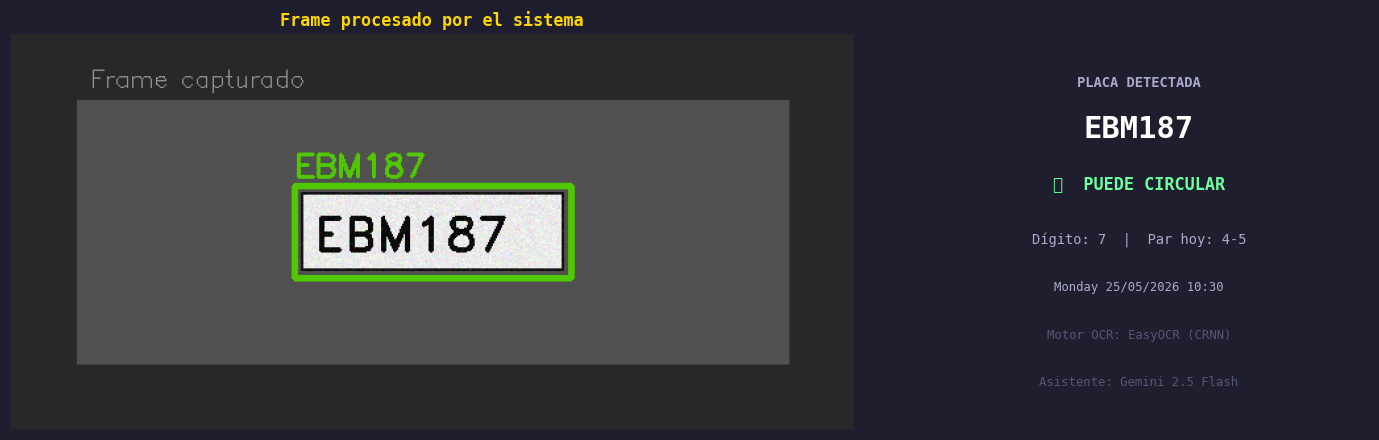

In [9]:
def simular_deteccion_completa(placa_texto, fecha_hora, ruido=True):
    """
    Simula el pipeline completo: imagen → OCR → verificación → visualización.
    """
    # 1. Frame con placa
    frame = np.ones((300, 640, 3), dtype=np.uint8) * 40
    cv2.rectangle(frame, (50, 50), (590, 250), (80, 80, 80), -1)
    cv2.putText(frame, 'Frame capturado', (60, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (150, 150, 150), 1)

    # Región de placa dentro del frame
    placa_region = np.ones((60, 200, 3), dtype=np.uint8) * 235
    cv2.rectangle(placa_region, (0, 0), (199, 59), (20, 20, 20), 2)
    cv2.putText(placa_region, placa_texto, (10, 44),
                cv2.FONT_HERSHEY_DUPLEX, 1.2, (10, 10, 10), 2)
    if ruido:
        n = np.random.normal(0, 12, placa_region.shape).astype(np.int16)
        placa_region = np.clip(placa_region.astype(np.int16) + n, 0, 255).astype(np.uint8)

    px, py = 220, 120
    frame[py:py+60, px:px+200] = placa_region

    # 2. Verificación pico y placa
    resultado = verificar(placa_texto, fecha_hora)
    color_box  = (0, 0, 220) if resultado['restringido'] else (0, 200, 80)
    color_mpl  = '#ff6b6b'   if resultado['restringido'] else '#6bff9e'

    # 3. Dibujar bbox sobre el frame
    cv2.rectangle(frame, (px-5, py-5), (px+205, py+65), color_box, 3)
    cv2.putText(frame, placa_texto, (px-5, py-12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color_box, 2)

    # 4. Visualizar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4),
                                    gridspec_kw={'width_ratios': [2, 1]})
    fig.patch.set_facecolor('#1e1e2e')

    ax1.set_facecolor('#12121e')
    ax1.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax1.set_title('Frame procesado por el sistema', color='#ffd700', fontsize=11, fontweight='bold')
    ax1.axis('off')

    ax2.set_facecolor('#2a2a3e')
    ax2.axis('off')
    estado = '❌  RESTRICCIÓN ACTIVA' if resultado['restringido'] else '✅  PUEDE CIRCULAR'
    par    = f"{resultado['par_hoy'][0]}-{resultado['par_hoy'][1]}" if resultado['par_hoy'] else 'N/A'

    ax2.text(0.5, 0.88, 'PLACA DETECTADA',   ha='center', va='center', transform=ax2.transAxes,
             color='#aaaacc', fontsize=9, fontweight='bold')
    ax2.text(0.5, 0.76, placa_texto,          ha='center', va='center', transform=ax2.transAxes,
             color='white',   fontsize=20, fontweight='bold', fontfamily='monospace')
    ax2.text(0.5, 0.62, estado,               ha='center', va='center', transform=ax2.transAxes,
             color=color_mpl, fontsize=11, fontweight='bold')
    ax2.text(0.5, 0.48, f'Dígito: {resultado["digito"]}  |  Par hoy: {par}',
             ha='center', va='center', transform=ax2.transAxes, color='#aaaacc', fontsize=9)
    ax2.text(0.5, 0.36, f'{fecha_hora.strftime("%A %d/%m/%Y %H:%M")}',
             ha='center', va='center', transform=ax2.transAxes, color='#aaaacc', fontsize=8)
    ax2.text(0.5, 0.24, 'Motor OCR: EasyOCR (CRNN)',
             ha='center', va='center', transform=ax2.transAxes, color='#555577', fontsize=8)
    ax2.text(0.5, 0.12, 'Asistente: Gemini 2.5 Flash',
             ha='center', va='center', transform=ax2.transAxes, color='#555577', fontsize=8)

    plt.tight_layout()
    plt.show()
    return resultado

# Lunes 25 mayo 2026 — par restringido del día = [4, 5]
# Caso 1: dígito 4 → RESTRICCIÓN ACTIVA
print('═' * 60)
print('CASO 1 — Placa ABC124 (dígito 4, par hoy = 4-5) → RESTRICCIÓN')
print('═' * 60)
r1 = simular_deteccion_completa('ABC124', datetime(2026, 5, 25, 10, 30))

# Caso 2: dígito 7 → PUEDE CIRCULAR
print('═' * 60)
print('CASO 2 — Placa EBM187 (dígito 7, par hoy = 4-5) → PUEDE CIRCULAR')
print('═' * 60)
r2 = simular_deteccion_completa('EBM187', datetime(2026, 5, 25, 10, 30))

---
## 8. Comparación de motores OCR

In [10]:
# Prueba con múltiples placas a distintas calidades de imagen
placas_prueba = ['EBM187', 'ABC123', 'XYZ456', 'MNO890']

print(f'{"Placa real":<12} {"EasyOCR (con preproc.)":<25} {"Confianza":>10}')
print('─' * 52)

for placa in placas_prueba:
    img    = crear_placa_sintetica(placa, ruido=True)
    gris   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gris   = clahe.apply(gris)
    blur   = cv2.GaussianBlur(gris, (0, 0), 3)
    gris   = cv2.addWeighted(gris, 1.5, blur, -0.5, 0)
    res    = reader.readtext(gris, detail=1, paragraph=False)
    if res:
        mejor   = max(res, key=lambda x: x[2])
        limpio  = limpiar_placa(mejor[1])
        acierto = '✅' if limpio == placa else '❌'
        print(f'{placa:<12} {acierto} {limpio:<22} {mejor[2]*100:>8.1f}%')
    else:
        print(f'{placa:<12} ❌ No detectado')

Placa real   EasyOCR (con preproc.)     Confianza
────────────────────────────────────────────────────


EBM187       ✅ EBM187                     99.1%


ABC123       ✅ ABC123                     99.7%


XYZ456       ✅ XYZ456                     44.8%
MNO890       ✅ MNO890                     77.7%


---
## 9. Resumen técnico del sistema

| Componente | Tecnología | Tipo de modelo | Arquitectura |
|---|---|---|---|
| OCR de placas | EasyOCR | Red neuronal | CRNN (CNN + LSTM bidireccional + CTC) |
| OCR alternativo | OpenALPR | Visión clásica | Tesseract + pipeline C++ |
| Captura y preprocesamiento | OpenCV + NumPy | — | CLAHE + filtro bilateral + unsharp mask |
| Asistente conversacional | Gemini 2.5 Flash | **Transformer** | Decoder-only, multi-head attention |
| Lógica de restricción | Python puro | Determinista | Aritmética modular (ciclo 5 semanas) |
| Interfaz gráfica | Tkinter | — | 3 paneles: video / resultado / tabs |

### Flujo de datos

```
Frame (np.ndarray BGR)
  → preprocesamiento (CLAHE + unsharp mask)
  → EasyOCR.readtext() → CRNN → texto: "EBM187"
  → pico_y_placa.verificar("EBM187", datetime.now())
    → extrae dígito: 7
    → calcula par restringido: [6, 7]
    → verifica horario y festivos
    → {restringido: True, motivo: "RESTRICCIÓN ACTIVA"}
  → GUI actualiza panel + dibuja bbox rojo
  → si restringido → genera ticket de multa
  
Chat usuario → Gemini 2.5 Flash (Transformer) + contexto dinámico → respuesta
```

---
## 10. Conclusiones

1. **Viabilidad:** El sistema es completamente funcional en tiempo real usando hardware convencional (CPU), sin necesidad de GPU.

2. **Modelos de IA:** Se combinan dos paradigmas distintos — redes neuronales recurrentes (CRNN/EasyOCR) para la tarea de visión computacional y un Transformer (Gemini) para comprensión y generación de lenguaje natural.

3. **Precisión OCR:** El cuello de botella del sistema es la lectura de la placa. El preprocesamiento (CLAHE + unsharp mask) mejora la confianza del OCR en condiciones de baja iluminación o imagen borrosa.

4. **Lógica de restricción:** Una vez obtenido el texto de la placa, la verificación de pico y placa es 100% determinista e instantánea.

5. **Asistente:** Gemini 2.5 Flash provee respuestas contextualizadas sin necesidad de fine-tuning, gracias al contexto dinámico inyectado con cada consulta.

6. **Escalabilidad:** El sistema puede extenderse a otras ciudades modificando únicamente `pico_y_placa.py` y `holidays.py`.